<a href="https://colab.research.google.com/github/wirkleysh/projeto_CD_wirkley/blob/main/Controle_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Projeto

In [ ]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 26.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct
import math

In [ ]:
# Monte o Google Drive para acessar os arquivos
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# TRATAMENTO DOS DADOS PARA LEVANTAMENTO DA FTMA

# Buscando o arquivo degral.csv no meu drive
caminho_arquivo = '/content/drive/MyDrive/Arquivo codigo /degrau.csv'

try:
  planta = open(caminho_arquivo).readlines()
except FileNotFoundError:
  print(f"Erro: '{caminho_arquivo}' não encontrado. Por favor, certifique-se de que o arquivo foi enviado para o Google Drive e a variável 'caminho_arquivo' aponta para o local correto.")
  raise # Relança o erro para parar a execução

t_orig = []
theta_orig = []
for i in range(len(planta)):
  if i>0: # Ignora linhas 0 (que contém a informações dos dados das colunas)
    linha = planta[i].split(",")
    t_orig.append(float(linha[0]))
    theta_orig.append(float(linha[1]))

t_orig = np.array(t_orig)
theta_orig = np.array(theta_orig)

theta_max_index = np.argmax(theta_orig)

theta_max = np.max(theta_orig)  # Mp = k*Mp - Maximo sobressinal(com a contante k)
Tp = t_orig[theta_max_index] # Tp - Tempo de pico
print(f"theta_max: {theta_max:.2f}")
print(f"Tp: {Tp:.2f}\n")

# Analizando os 10% dos pontos finas do grafico para encontrar k
tamanho_janela  = len(theta_orig)//10 # Valor de 10% dos pontos totais
print(f"tamanho_janela: {tamanho_janela}\n")

# Cálculo de k e Mp
theta_rp = np.mean(theta_orig[-tamanho_janela:]) # Media dos 10% pontos finais para aquisição do valor em RP
k = theta_rp
Mp = (theta_max - theta_rp)/theta_max
print(f"k: {k:.2f}")
print(f"Mp: {Mp:.4f}")

# Cálculo de zeta e wn
zeta = -np.log(Mp)/np.sqrt(np.pi**2 + np.log(Mp)**2)
wd = np.pi/Tp
wn = wd/np.sqrt(1 - zeta**2)
print(f"Zeta: {zeta:.3f}")
print(f"Wd: {wd:.3f}\n")
print(f"Wn: {wn:.3f}")

theta_max: 5.74
Tp: 41.37

tamanho_janela: 1500

k: 5.23
Mp: 0.0881
Zeta: 0.612
Wd: 0.076

Wn: 0.096


G(s):
 <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

           0.04823
  -------------------------
  s^2 + 0.1175 s + 0.009216



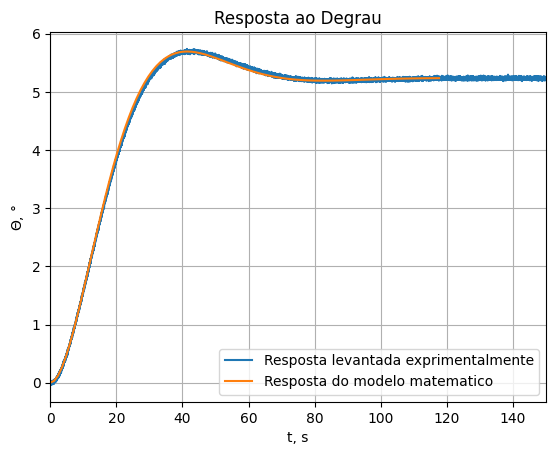

In [ ]:
# FUNÇÃO TRANSFERÊNCIA G(s)

# Definir numerador e denominador da função transferencia G(s)
numG = [k*wn**2] #
denG = [1, 2*zeta*wn, wn**2]

# Criando  a função transferencia G
G = ct.TransferFunction(numG, denG)

# imprime função transferencia
print(f"G(s):\n {G}\n")

t_g, theta_g = ct.step_response(G)

#Plotando o gráfico
plt.figure()
plt.plot(t_orig,theta_orig, label='Resposta levantada exprimentalmente')
plt.plot(t_g, theta_g, label='Resposta do modelo matematico')
plt.xlabel('t, s')
plt.ylabel(r'$\Theta$, °')
plt.legend(loc='best')
plt.grid()
plt.xlim(0,150)
plt.title('Resposta ao Degrau')
plt.show()

In [ ]:
# Calculo das informações da respota ao degrau da G(s)
step_info_G = ct.step_info(G)

# Extraindo e plotando as especifiçãoes da função ct.step_info
print(f"Tr: {step_info_G['RiseTime']:.2f} s")
print(f"Tp: {step_info_G['PeakTime']:.2f} s")
print(f"Mp: {step_info_G['Overshoot']:.2f}%")
print(f"Ts: {step_info_G['SettlingTime']:.2f} s (2% tolerancia)")
print(f"theta_rp: {step_info_G['SteadyStateValue']:.2f}")

Tr: 19.01 s
Tp: 41.58 s
Mp: 8.80%
Ts: 62.97 s (2% tolerancia)
theta_rp: 5.23


C(s):
 <TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = None

  1
  -
  1

FTMF:
 <TransferFunction>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          0.04823
  ------------------------
  s^2 + 0.1175 s + 0.05745



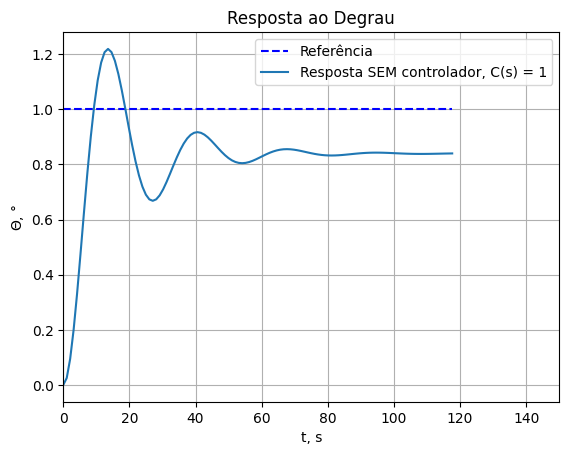

In [ ]:
# Controlador: C(s) = 1
C1 = ct.TransferFunction([1],[1])
print(f"C(s):\n {C1}\n")

# FTMF: T(s) = C(s)G(s) / (1 + C(s)G(s))
T1 = ct.feedback(C1 * G)
print(f"FTMF:\n {T1}\n")

t_t1, theta_t1 = ct.step_response(T1)
step = np.ones_like(t_t1) * 1.0 # Define a reference step signal of amplitude 1.0

#Plotando o gráfico
plt.figure()
plt.plot(t_t1, step, 'b--', label='Referência') # Plot the reference step
plt.plot(t_t1, theta_t1, label='Resposta SEM controlador, C(s) = 1')
plt.xlabel('t, s')
plt.ylabel(r'$\Theta$, °')
plt.legend(loc='best')
plt.grid()
plt.xlim(0,150)
plt.title('Resposta ao Degrau')
plt.show()

In [ ]:
# Calculo das informações da respota ao degrau da T1(s)
step_info_T1 = ct.step_info(T1)

# Extraindo e plotando as especifiçãoes da função ct.step_info
print(f"Tr: {step_info_T1['RiseTime']:.2f} s")
print(f"Tp: {step_info_T1['PeakTime']:.2f} s")
print(f"Mp: {step_info_T1['Overshoot']:.2f}%")
print(f"Ts: {step_info_T1['SettlingTime']:.2f} s (2% tolerancia)")
print(f"theta_rp: {step_info_T1['SteadyStateValue']:.2f}")

# Erro de regime permanente
erro_T1 = 1/(k+1)
print(f"\nErro_RP(matematico): {erro_T1:.2f}")

erro_T1_G = step[-10] - theta_t1[-10]
print(f"Erro_RP(empirico): {erro_T1_G:.2f}")

Tr: 5.20 s
Tp: 13.53 s
Mp: 45.20%
Ts: 59.33 s (2% tolerancia)
theta_rp: 0.84

Erro_RP(matematico): 0.16
Erro_RP(empirico): 0.16


In [ ]:
# Funções para respostas de funções trigonometricas em graus

def sind(angulo_graus):
  return math.sin(math.radians(angulo_graus))

def cosd(angulo_graus):
  return math.cos(math.radians(angulo_graus))

def tand(angulo_graus):
  return math.tan(math.radians(angulo_graus))

def arctand(valor):
  return math.degrees(math.atan(valor))

In [ ]:
# CONTROLADOR PID

# Variaveis
Mp_ftmf = 0.2
Ts_2_ftmf = 47

# Calcular o polos da G(s)
p0 = np.roots(denG)[0]
p1 = np.roots(denG)[1]

# Separando a parte real (sigma) e imaginária (w) dos polos
sigma_p0 = p0.real
w_p0 = p0.imag
sigma_p1 = p1.real
w_p1 = p1.imag

print(f"s_p0 = {sigma_p0:.4f} {w_p0:.4f}j")
print(f"s_p1 = {sigma_p1:.4f} {w_p1:.4f}j \n")

# Calculando zeta e wn
zeta_ftmf = -np.log(Mp_ftmf)/np.sqrt(np.pi**2 + np.log(Mp_ftmf)**2)
wn_ftmf = 4/(Ts_2_ftmf*zeta_ftmf)
print(f"zeta_ftmf = {zeta_ftmf:.3f}")
print(f"wn_ftmf = {wn_ftmf:.3f}\n")

# Definir ponto a que o Root Locus deve mapear
sigma_i = - wn_ftmf*zeta_ftmf
w_i = np.sqrt(wn_ftmf**2 - sigma_i**2)
print(f"sigma_i = {sigma_i:.2f}")
print(f"w_i = {w_i:.2f}\n")

# Ponto que o RL precisa mapear
print(f"s = {sigma_i:.2f} + j{w_i:.2f}\n")

s_p0 = -0.0587 0.0759j
s_p1 = -0.0587 -0.0759j 

zeta_ftmf = 0.456
wn_ftmf = 0.187

sigma_i = -0.09
w_i = 0.17

s = -0.09 + j0.17



In [ ]:
# Condição Angular
# theta_pid
alfa_pid = arctand(w_i/np.abs(sigma_i))
theta_pid = 180 - alfa_pid
print(f"theta_pid = {theta_pid:.2f}")

# theta_p0
alfa_p0 = arctand((w_i - w_p0)/(np.abs(sigma_i) - np.abs(sigma_p0)))
theta_p0 = 180 - alfa_p0
print(f"theta_p0 = {theta_p0:.2f}")

# theta_p1
alfa_p1 = arctand((w_i - w_p1)/(np.abs(sigma_i) - np.abs(sigma_p1)))
theta_p1 = 180 - alfa_p1
print(f"theta_p1 = {theta_p1:.2f}")

# Calculo de theta_z0 e theta_z1
theta_z0 = 80 # atribuindo um valor a theta_z0
theta_z1 = theta_pid + theta_p0 + theta_p1 - theta_z0 -180
print(f"theta_z0 = {theta_z0:.2f}")
print(f"theta_z1 = {theta_z1:.2f}\n")

# Calculo de z0 e z1
if theta_z0 > 90:
  x0 = w_i/tand(180 - theta_z0)
  z0 = sigma_i + x0
elif theta_z0 == 90:
  z0 = sigma_i
else:
  x0 = w_i/tand(theta_z0)
  z0 = sigma_i - x0

if theta_z1 > 90:
  x1 = w_i/tand(180 - theta_z1)
  z1 = sigma_i + x1
elif theta_z1 == 90:
  z1 = sigma_i
else:
  x1 = w_i/tand(theta_z1)
  z1 = sigma_i - x1

print(f"z0 = {z0:.2f}")
print(f"z1 = {z1:.2f}\n")

theta_pid = 117.13
theta_p0 = 106.30
theta_p1 = 96.22
theta_z0 = 80.00
theta_z1 = 59.65

z0 = -0.11
z1 = -0.18



In [ ]:
# calculo kp, ki e kd
Az0 = np.sqrt(w_i**2 + (sigma_i - z0)**2)
Az1 = np.sqrt(w_i**2 + (sigma_i - z1)**2)

Ap0 = np.sqrt((w_i - w_p0)**2 + (sigma_i - sigma_p0)**2)
Ap1 = np.sqrt((w_i - w_p1)**2 + (sigma_i - sigma_p1)**2)

Apid = np.sqrt(w_i**2 + sigma_i**2)

kd = (Ap0*Ap1*Apid)/(numG[0]*Az0*Az1) # Ganho derivativo
kp = np.abs(z0 + z1)*kd # Ganho propocional
ki = np.abs(z0*z1)*kd # Ganho integral

print(f"kp = {kp:.2f}")
print(f"ki = {ki:.2f}")
print(f"kd = {kd:.2f}\n")

# Definir numerador e denominador da função transferencia C(s)
numC = [kd, kp, ki] # Representa numerador de C(s)
denC = [1, 0] # Representa denominador de C(s)
C = ct.tf(numC,denC) # Controlador: C(s)
print(f"C(s):\n {C}\n")

# FTMF: T(s) = C(s)G(s) / (1 + C(s)G(s))
T = ct.feedback(C * G)
print(f"FTMF:\n {T}\n")
print(f'Zeros:\ns = {np.roots(numC)[0]:.2f}\ns = {np.roots(numC)[1]:.2f}')

kp = 0.81
ki = 0.06
kd = 2.73

C(s):
 <TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  2.726 s^2 + 0.8092 s + 0.05689
  ------------------------------
                s

FTMF:
 <TransferFunction>: sys[16]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.1315 s^2 + 0.03903 s + 0.002744
  --------------------------------------
  s^3 + 0.249 s^2 + 0.04825 s + 0.002744

Zeros:
s = -0.18
s = -0.11


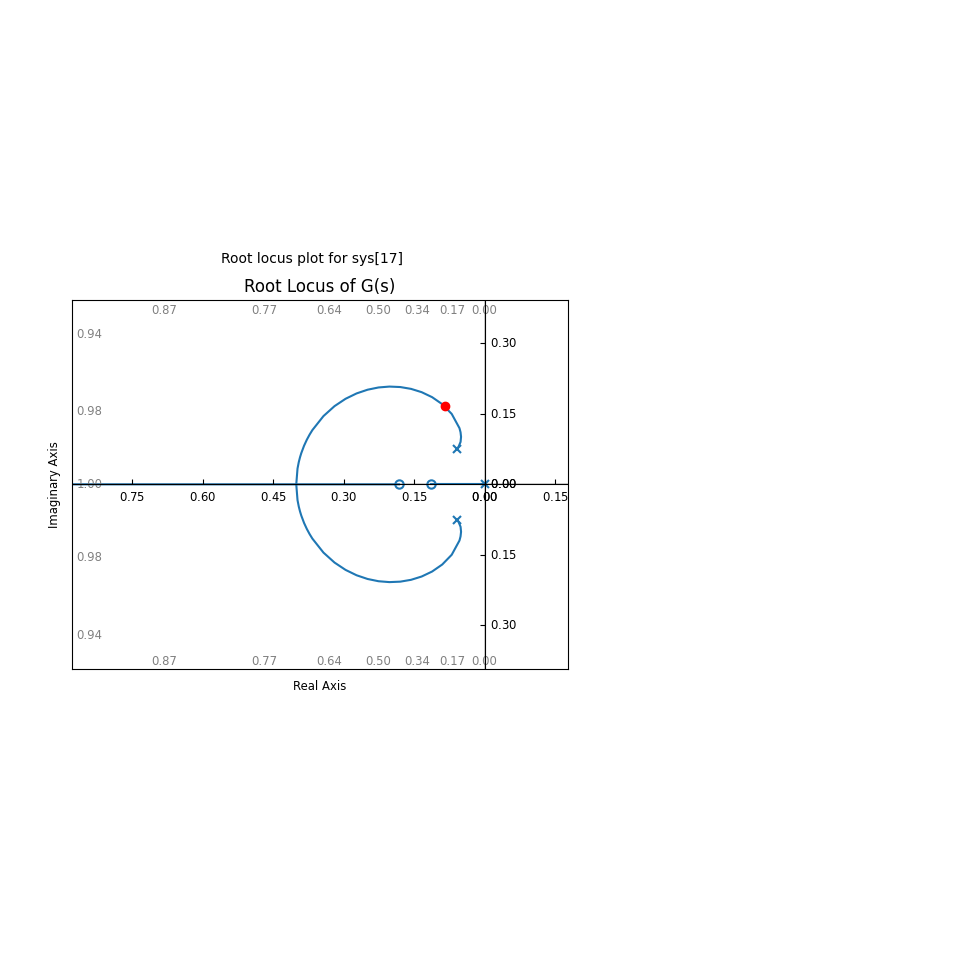

In [ ]:
# Plotando RL com ponto dejado de mapear
plt.figure()
ct.root_locus(C*G)
plt.plot(sigma_i, w_i, 'ro')
plt.title('Root Locus of G(s)')
plt.xlabel('Real Axis')
plt.ylabel('Imaginary Axis')
plt.grid()
plt.show()

In [ ]:
# Calculo das informações da respota ao degrau da T(s)
step_info_T = ct.step_info(T)

# Extraindo e plotando as especifiçãoes da função ct.step_info
print(f"Tr: {step_info_T['RiseTime']:.2f} s")
print(f"Tp: {step_info_T['PeakTime']:.2f} s")
print(f"Mp: {step_info_T['Overshoot']:.2f}%")
print(f"Ts: {step_info_T['SettlingTime']:.2f} s (2% tolerancia)")
print(f"theta_rp: {step_info_T['SteadyStateValue']:.2f}")

Tr: 7.09 s
Tp: 15.06 s
Mp: 15.25%
Ts: 42.53 s (2% tolerancia)
theta_rp: 1.00


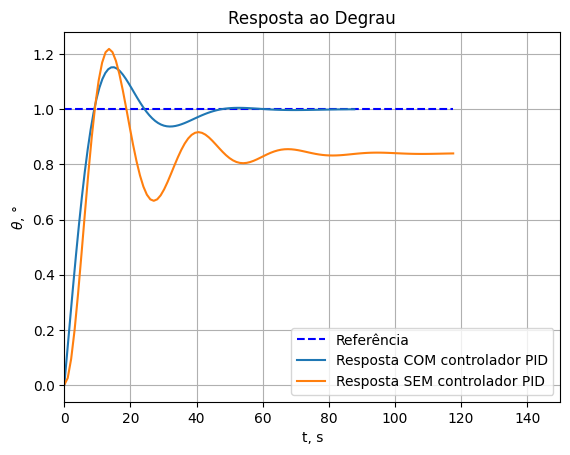

In [ ]:
# Plotando noo gráfico as curvas com controlador PID, sem controlador PID e referncia
t_t, theta_t = ct.step_response(T)
step = np.ones_like(t_t1) * 1.0 # Define a reference step signal of amplitude 1.0

plt.figure()
plt.plot(t_t1, step, 'b--', label='Referência') # Plot the reference step
plt.plot(t_t, theta_t, label='Resposta COM controlador PID')
plt.plot(t_t1, theta_t1, label='Resposta SEM controlador PID')
plt.xlabel('t, s')
plt.ylabel(r'$\theta$, °')
plt.legend(loc='lower right')
plt.grid()
plt.xlim(0,150)
plt.title('Resposta ao Degrau')
plt.show()

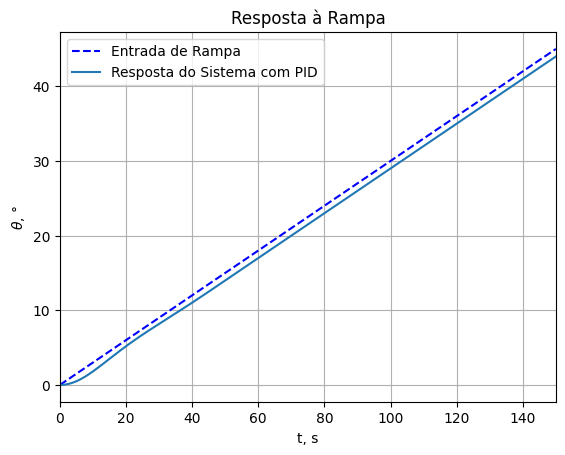

Erro_RP: 1.01


In [ ]:
# Definir o coeficiente angular da rampa
theta_ref = 30
t_ref = 100
coef_angular = theta_ref / t_ref

# Gerar o sinal de rampa
t_ramp = np.linspace(0, 150, 1000) # Usar o mesmo intervalo de tempo dos outros gráficos
ramp_input = coef_angular * t_ramp

# Calcular a resposta do sistema (T) à entrada de rampa
t_out_ramp, y_out_ramp = ct.forced_response(T, T=t_ramp, U=ramp_input)

# Plotar a resposta à rampa
plt.figure()
plt.plot(t_ramp, ramp_input, 'b--', label='Entrada de Rampa')
plt.plot(t_out_ramp, y_out_ramp, '', label='Resposta do Sistema com PID')
plt.xlabel('t, s')
plt.ylabel(r'$\theta$, °')
plt.legend(loc='upper left')
plt.grid(True)
plt.title('Resposta à Rampa')
plt.xlim(0, 150)
plt.show()

# Erro de regime permanente
erro_T_rampa = ramp_input[-1] - y_out_ramp[-1]
print(f"Erro_RP: {erro_T_rampa:.2f}")